# Quantum Teleportation Protocol


## Libreries

In [10]:
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.quantum_info import random_statevector, Statevector
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.quantum_info import Statevector, partial_trace, state_fidelity

from IPython.display import display, Markdown

import numpy as np

## Helpful functions

In [11]:
def _latex_label(state):
    """Map state identifier to Unicode-friendly label."""
    return {"phi+": "Φ+", "phi-": "Φ-", "psi+": "Ψ+", "psi-": "Ψ-"}[state]


def fix_global_phase(state_target: Statevector, state_source: Statevector) -> Statevector:
    """ Delete global phase from state_target to align it with state_source."""
    # Obtain the difference in phase for the first element |0>
    phase_diff = np.angle(state_source.data[0]) - np.angle(state_target.data[0])
    # Apply the inverse phase rotation
    corrected_data = state_target.data * np.exp(1j * phase_diff)
    return Statevector(corrected_data)

## Definition of Φ+ Bell State Quantum Circuit (EPR State)

In [12]:
def build_bell_circuit(state):
    """
    Build the quantum circuit for the specified Bell state.

    The construction follows two steps:
        1. Hadamard on qubit 0  →  creates superposition |+⟩ on q_0
        2. CNOT (q0 → q1)       →  entangles both qubits

    Additional single-qubit corrections are applied before H to reach
    the other three Bell states:
        |Φ-⟩  →  Z on q_0 after H  (phase flip)
        |Ψ+⟩  →  X on q_1 before H  (bit flip on target)
        |Ψ-⟩  →  X on q_1 + Z on q_0

    Args:
        state: One of "phi+", "phi-", "psi+", "psi-". Defaults to "phi+".

    Returns:
        QuantumCircuit: Parameterised circuit with 2 qubits and 2 classical bits.

    Raises:
        ValueError: If an unknown state label is provided.
    """
    valid = {"phi+", "phi-", "psi+", "psi-"}
    if state not in valid:
        raise ValueError(f"Unknown Bell state '{state}'. Choose from {valid}.")

    qc = QuantumCircuit(2, name=f"Bell |{_latex_label(state)}⟩")


    # ── Step 1: optional pre-corrections ────────────────────────────────────
    if state in ("psi+", "psi-"):
        # Flip target qubit so entanglement produces |01⟩ + |10⟩ basis
        qc.x(1)

    # ── Step 2: Hadamard on control qubit ───────────────────────────────────
    # H |0⟩ = (|0⟩ + |1⟩) / √2  →  equal superposition
    qc.h(0)

    # ── Step 3: optional phase flip ─────────────────────────────────────────
    if state in ("phi-", "psi-"):
        # Z introduces a relative phase: H Z |0⟩ = (|0⟩ - |1⟩) / √2
        qc.z(0)

    # ── Step 4: CNOT — creates entanglement ─────────────────────────────────
    # If q0 = |1⟩, flip q1.  Result: correlated |00⟩ + |11⟩ (or |01⟩ + |10⟩)
    qc.cx(0, 1)

    return qc

## Quantum Teleportation Quantum Circuit

In [ ]:
def build_quantum_teleportation_circuit(epr_state, quantum_state):
    """
        Build the quantum circuit for the Quantum Teleportation protocol.
    
        The construction follows two steps:
            1. Bell state preparation (q1 and q2)  →  creates entangled pair
            2. CNOT (q0 → q1)       →  entangles both qubits
            3. Hadamard on qubit 0  →  creates superposition |+⟩ on q_0
            4. Measurement of q0 and q1  →  collapses the state of q2 to the teleported state
    
        Args:
            state: Bell state "phi+" as EPR state.
            quantum_state: The quantum state to be teleported.
    
        Returns:
            QuantumCircuit: Parameterised circuit with 3 qubits and 2 classical bits.
    
        Raises:
            ValueError: If an unknown Bell state "phi+" label is provided.
    """

    valid = {"phi+"}

    if epr_state not in valid:
            raise ValueError(f"Invalid EPR state '{epr_state}'. Choose from {valid}.")

    qr = QuantumRegister(3, name="q")
    cr = ClassicalRegister(2, name="c")    
    qc_quantum_teleportation = QuantumCircuit(qr, cr, name="Quantum Teleportation for State Ψ")

    qc_quantum_teleportation.initialize(quantum_state, 0)

    qc_quantum_teleportation.append(build_bell_circuit(epr_state), [1, 2])

    qc_quantum_teleportation.cx(0, 1)

    qc_quantum_teleportation.h(0)

    qc_quantum_teleportation.measure([0, 1], [0, 1])

    # If bit 1 is 1 (c[1] == 1) -> Apply X gate
    with qc_quantum_teleportation.if_test((cr[1], 1)):
        qc_quantum_teleportation.x(qr[2])

    # If bit 0 is 1 (c[0] == 1) -> Apply Z gate
    with qc_quantum_teleportation.if_test((cr[0], 1)):
        qc_quantum_teleportation.z(qr[2])


    return qc_quantum_teleportation

## Build the Quantum Circuit and draw it

### Choose the Bell state Φ+

In [14]:
EPR_state = "phi+".strip()
# Generate a random state vector for 1 qubit
quantum_state = random_statevector(2, seed=42)  # 'seed' is optional for reproducibility
quantum_state_latex = quantum_state.draw('text')


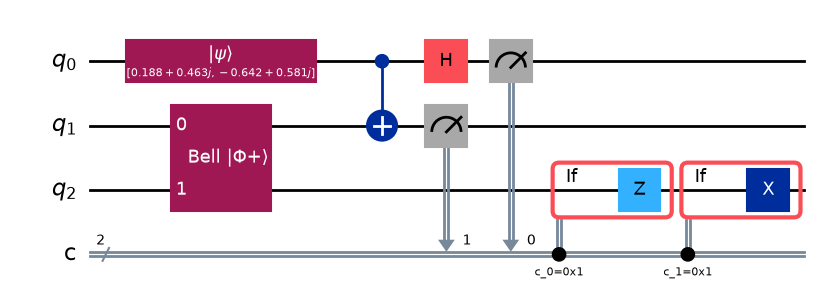

In [15]:
qc_quantum_teleportation = build_quantum_teleportation_circuit(EPR_state, quantum_state)
fig_quantum_teleportation = qc_quantum_teleportation.draw(output="mpl", fold=-1)
fig_quantum_teleportation

## Execute de Circuit using the Quantum State 

In [16]:
backend = AerSimulator(method="statevector")
qc_sim = qc_quantum_teleportation.copy()
qc_sim.save_density_matrix()  


# Transpile and execute
transpiled = transpile(qc_sim, backend, optimization_level=1)
result = backend.run(transpiled).result()

# Density matrix of the entire circuit
rho_total = result.data()["density_matrix"]

# Delete q0 and q1 by partial trace to isolate the state of qubit q2 (Bob)
rho_bob = partial_trace(rho_total, [0, 1])

# Get the initial state of Alice
state_alice = Statevector(quantum_state)

# Calculate the fidelity between the initial state of Alice and the final state of Bob
fidelity = state_fidelity(state_alice, rho_bob)

state_bob = rho_bob.to_statevector()

state_bob_corrected = fix_global_phase(state_bob, state_alice)



## Check the results

In [19]:
print(f"\n{'='*50}")
print(f"Quantum Teleportation Protocol")
print(f"{'='*50}")

print(f"\nRandom Quantum State Ψ to teleport: |Ψ⟩ = α|0⟩ + β|1⟩")
print(f"Quantum State Ψ — {quantum_state_latex}")
print(f"Bell State/ EPR State — phi+ ({_latex_label(EPR_state)})\n")

print("--- Qubit 0 state (Alice initial) ---")
print(state_alice.draw('text')) 
print()
print("--- Qubit 2 state (Bob final) ---")
print(state_bob_corrected.draw('text'))

print("\n")
print(f"Fidelity: {fidelity:.6f}\n")


Quantum Teleportation Protocol

Random Quantum State Ψ to teleport: |Ψ⟩ = α|0⟩ + β|1⟩
Quantum State Ψ — [ 0.18817376+0.4634306j ,-0.64222759+0.58083254j]
Bell State/ EPR State — phi+ (Φ+)

--- Qubit 0 state (Alice initial) ---
[ 0.18817376+0.4634306j ,-0.64222759+0.58083254j]

--- Qubit 2 state (Bob final) ---
[ 0.18817376+0.4634306j ,-0.64222759+0.58083254j]


Fidelity: 1.000000

